### Build a Basic Chatbot With LangGraph(GRAPH API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
     # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]
graph_builder=StateGraph(State)   
 

In [3]:
graph_builder

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama-3.1-8b-instant")

In [6]:
llm

ChatGroq(metadata={'versions': {'langchain-core': '1.4.6', 'langchain': '1.3.8'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000027B571086E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000027B57488170>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
def chatbot(state:State):
    return{"messages":[llm.invoke(state["messages"])]}

In [8]:
graph_builder=StateGraph(State) 

## Adding Node
graph_builder.add_node("llmchatbot",chatbot)

## Adding Node
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)


##compile the graph
graph=graph_builder.compile()



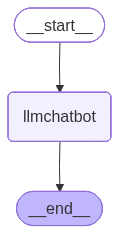

In [9]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:    
    pass

In [10]:
response=graph.invoke({"messages":"Hi"})

In [11]:
response["messages"]

[HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='c453bda4-ed51-437b-91e8-8e07e144c7af'),
 AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.024066313, 'completion_tokens_details': None, 'prompt_time': 0.002483454, 'prompt_tokens_details': None, 'queue_time': 0.048773136, 'total_time': 0.026549767}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ebcb7-b5d0-7700-92a5-a51e5c87409b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})]

In [12]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [13]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():

     print(value["messages"][-1].content)

I'm just a computer program, so I don't have feelings, but thank you for asking. How can I assist you today?


## Chatbot With Tools

In [14]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is LangGarph?")

{'query': 'What is LangGarph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the 

In [15]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b
    
    Args:
        a (int): first int
        b (int):second int
        
    Returns:
        int: output int
  """
    return a*b

In [16]:
tools=[tool,multiply]

In [17]:
llm_with_tools=llm.bind_tools(tools)

In [18]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'versions': {'langchain-core': '1.4.6', 'langchain': '1.3.8'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000027B571086E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000027B57488170>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine op

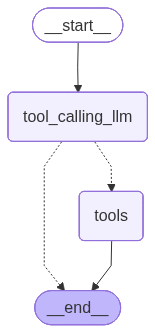

In [19]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return{"messages":[llm_with_tools.invoke(state["messages"])]}


## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))




In [20]:
response=graph.invoke({"messages":"What is the recent ai news?"})

In [21]:
response['messages'][-1].content

'{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cbsnews.com/news/ai-backlash-college-commencements-2026/", "title": "Recent commencement speeches show students are souring on AI. How deep is the angst? - CBS News", "score": 0.7211353, "published_date": "Tue, 19 May 2026 21:19:31 GMT", "content": "She previously worked at \\"60 Minutes,\\" CBSNews.com and CBS News 24/7 as part of the CBS News Associate Program. That dynamic was on full display on Sunday, when University of Arizona students jeered former Google CEO Eric Schmidt during his commencement speech as he discussed the future of AI, according to an online video of his remarks posted by the school. Recent data from\xa0Gallup captures the growing pessimism: 43% of people ages 15 to 34 think it\'s a good time to find a job, down from 75% in 2022, and 21 percentage points lower than those 55 and older. Part of that wariness is showing up in concerns about the j

In [22]:
for m in response['messages']:
 m.pretty_print()

================================ Human Message =================================

What is the recent ai news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (qd7ftaw20)
 Call ID: qd7ftaw20
  Args:
    query: recent ai news
    time_range: month
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cbsnews.com/news/ai-backlash-college-commencements-2026/", "title": "Recent commencement speeches show students are souring on AI. How deep is the angst? - CBS News", "score": 0.7211353, "published_date": "Tue, 19 May 2026 21:19:31 GMT", "content": "She previously worked at \"60 Minutes,\" CBSNews.com and CBS News 24/7 as part of the CBS News Associate Program. That dynamic was on full display on Sunday, when University of Arizona students jeered form

In [23]:
response=graph.invoke({"messages":"What is 5 multiply by 2?"})

In [24]:
for m in response['messages']:
 m.pretty_print()

================================ Human Message =================================

What is 5 multiply by 2?
================================== Ai Message ==================================
Tool Calls:
  multiply (486d3crb2)
 Call ID: 486d3crb2
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [25]:

response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (veds92nac)
 Call ID: veds92nac
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (w8cp5s0b4)
 Call ID: w8cp5s0b4
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.telecoms.com/ai/ai-app-disruption-is-on-the-up", "title": "AI app disruption is on the up - Telecoms", "score": 0.6058229, "published_date": "Fri, 12 Jun 2026 08:44:16 GMT", "content": "# AI app disruption is on the up. AI application disruption rocketed in the first quarter of this year, according to new analyst data that will sound a warning note to enterpri

## ReactAgent Architecture

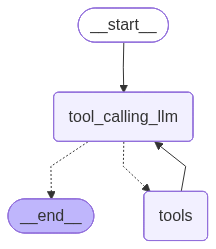

In [26]:

## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:

response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (n4sw2bpm4)
 Call ID: n4sw2bpm4
  Args:
    query: recent ai news
    time_range: week
    topic: news
  multiply (z5k6eecnc)
 Call ID: z5k6eecnc
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/2026/06/11/anthropic-openai-london-expansions-big-tech.html", "title": "Anthropic, OpenAI, other U.S. AI giants launch major London expansions amid talent and revenue scramble - CNBC", "score": 0.6654328, "published_date": "Thu, 11 Jun 2026 10:19:29 GMT", "content": "# Anthropic, OpenAI, other U.S. AI giants launch major London expansions amid talent

## Adding Memory in Agentic Graph

In [28]:

response=graph.invoke({"messages":"Hello my name is Khushi"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Khushi
================================== Ai Message ==================================

It's nice to meet you, Khushi. Is there anything I can help you with today?


In [29]:
response=graph.invoke({"messages":"What is my Name?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my Name?
================================== Ai Message ==================================

I don't have any information about your name. If you'd like to share it with me, I can try to remember it for our conversation.


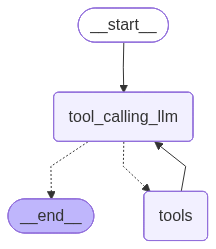

In [30]:

## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [31]:
config= {"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Khushi"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is Khushi', additional_kwargs={}, response_metadata={}, id='cff8fada-1b88-433b-bcfc-9a83bb6d19cc'),
  AIMessage(content='Nice to meet you, Khushi. How are you doing today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 1751, 'total_tokens': 1766, 'completion_time': 0.024567405, 'completion_tokens_details': None, 'prompt_time': 0.242467602, 'prompt_tokens_details': None, 'queue_time': 0.092114616, 'total_time': 0.267035007}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ebcb8-e542-7011-9136-b7109838c550-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1751, 'output_tokens': 15, 'total_tokens': 1766})]}

In [32]:
response['messages'][-1].content

'Nice to meet you, Khushi. How are you doing today?'

In [33]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Your name is Khushi.


In [34]:
response=graph.invoke({"messages":"Hey do you remember my is name"},config=config)

print(response['messages'][-1].content)

Your name is Khushi.


### streaming

In [35]:

from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [36]:

def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

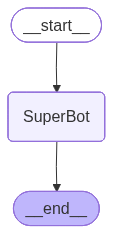

In [37]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [38]:
## Invocation

config={"configurable":{"thread_id": "1"}}

graph_builder.invoke({"messages":"Hi, My name is khushi And I like cricket"},config)

{'messages': [HumanMessage(content='Hi, My name is khushi And I like cricket', additional_kwargs={}, response_metadata={}, id='2cf9003c-3fb3-432b-9658-3eea0ff04141'),
  AIMessage(content="Hello Khushi, nice to meet you.  It's great to hear that you like cricket! Cricket is a fantastic sport with a huge global following. Which team or player is your favorite in the world of cricket?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 46, 'total_tokens': 91, 'completion_time': 0.069585569, 'completion_tokens_details': None, 'prompt_time': 0.002154909, 'prompt_tokens_details': None, 'queue_time': 0.045695558, 'total_time': 0.071740478}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ebcb9-ba5f-7b53-8da7-39defe612d7f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'outpu


## Streaming
Methods: .stream() and astream()

These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

values : This streams the full state of the graph after each node is called.
updates : This streams updates to the state of the graph after each node is called.

In [39]:

# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Khushi And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Khushi. Cricket is a fantastic sport, and I'm sure you have your favorite teams and players. Are you an avid fan of international cricket or do you have a special interest in domestic leagues like the Indian Premier League (IPL)?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 46, 'total_tokens': 100, 'completion_time': 0.10633089, 'completion_tokens_details': None, 'prompt_time': 0.003357696, 'prompt_tokens_details': None, 'queue_time': 0.048896564, 'total_time': 0.109688586}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ebcb9-bbc7-7da3-be52-d45967dccd9b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 54, 'total_tokens': 100})]}}


In [40]:



for chunk in graph_builder.stream({'messages':"Hi,My name is Khushi And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Khushi And I like cricket', additional_kwargs={}, response_metadata={}, id='12159cd9-96bd-4dc4-8728-a83679d2c62d'), AIMessage(content="Nice to meet you, Khushi. Cricket is a fantastic sport, and I'm sure you have your favorite teams and players. Are you an avid fan of international cricket or do you have a special interest in domestic leagues like the Indian Premier League (IPL)?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 46, 'total_tokens': 100, 'completion_time': 0.10633089, 'completion_tokens_details': None, 'prompt_time': 0.003357696, 'prompt_tokens_details': None, 'queue_time': 0.048896564, 'total_time': 0.109688586}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ebcb9-bbc7-7da3-be52-d45967dccd9b-0', tool_calls=[], invalid_tool_call

In [41]:

# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Khushi And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Khushi. Cricket is a great sport, isn't it? Which team or player is your favorite in international cricket? Are you more into the Indian Premier League (IPL) or Test matches?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 46, 'total_tokens': 92, 'completion_time': 0.104491125, 'completion_tokens_details': None, 'prompt_time': 0.002161789, 'prompt_tokens_details': None, 'queue_time': 0.047708821, 'total_time': 0.106652914}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ebcb9-bf91-7153-945b-fc228becaf69-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 46, 'total_tokens': 92})]}}


In [42]:
for chunk in graph_builder.stream({'messages':"I also like football"},config, stream_mode="values"):
      print(chunk)                            

{'messages': [HumanMessage(content='Hi,My name is Khushi And I like cricket', additional_kwargs={}, response_metadata={}, id='ddf80f9e-e227-433d-a9a0-e0ff8e1eefe4'), AIMessage(content="Nice to meet you, Khushi. Cricket is a great sport, isn't it? Which team or player is your favorite in international cricket? Are you more into the Indian Premier League (IPL) or Test matches?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 46, 'total_tokens': 92, 'completion_time': 0.104491125, 'completion_tokens_details': None, 'prompt_time': 0.002161789, 'prompt_tokens_details': None, 'queue_time': 0.047708821, 'total_time': 0.106652914}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ebcb9-bf91-7153-945b-fc228becaf69-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_token

In [43]:


config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ebcb9-c34e-7360-be4a-5fb053d18c7f', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='80690dbd-e957-4c02-ab53-4e31964fcc9f')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019ebcb9-c353-7e81-84e5-cb2c5758bf5d', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:1307b6ab-9a2e-9f32-92d8-b7e57dfad1d9'}, 'parent_ids': ['019ebcb9-c34e-7360-be4a-5fb053d18c7f']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':